# Лабораторна Робота №2 - Аналіз та прогнозування енергоспоживання
**Об'єкт:** Поліклініка Київ | **Площа:** 850 м² | **Режим:** 08:00-20:00


## 0. Налаштування: шлях до проекту та імпорти

In [1]:

import os, sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

from backend.config.config import get_settings
from backend.app.database  import session_scope, check_connection

from backend.app.forecasting.feature_engineering import (
    load_raw_data, clean_data, build_features,
    prepare_ml_dataset, train_test_split_temporal,
    get_feature_columns, TARGET
)
from backend.app.forecasting.models        import train_all_models, best_model_name, evaluate
from backend.app.forecasting.model_loader  import save_all_models, save_metadata, list_saved_models
from backend.app.forecasting.forecast_service import ForecastService

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn  as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette("husl")

# ── Config from ЛР1 settings.yaml ────────────────────────────────────────────
settings = get_settings()
AREA_M2 = settings.object.area_m2
HDD_BASE = settings.weather.hdd_base_temp_c
CDD_BASE = settings.weather.cdd_base_temp_c
DAY_RATE = next(z.rate_uah_kwh for z in settings.tariff.zones if z.zone_type=='day')
NGHT_RATE = next(z.rate_uah_kwh for z in settings.tariff.zones if z.zone_type=='night')
SOLAR_KW = settings.solar.capacity_kw
MODELS_DIR = Path('..') / settings.forecasting.models_dir
REPORTS_DIR = Path('../reports')
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

MONTHS_UA = ['Сiч','Лют','Бер','Квi','Тра','Чер','Лип','Сер','Вер','Жов','Лис','Гру']

print(f"Object: {settings.object.name}")
print(f"Area: {AREA_M2} m2 Solar: {SOLAR_KW} kW")
print(f"Tariff: day {DAY_RATE} UAH | night {NGHT_RATE} UAH")
print(f"DB OK: {check_connection()}")


Project root: d:\VS\VS_Code Projects\PZ\PZ-main
Object: Поліклініка Київ
Area: 850.0 m2 Solar: 35.0 kW
Tariff: day 6.9 UAH | night 5.6 UAH
DB OK: True


## 1. Завантаження даних (ЛР1 БД)

In [2]:

with session_scope() as db:
    raw = load_raw_data(db)

print(f"Рядків: {len(raw):,}")
print(f"Перiод: {raw.index.min().date()} -> {raw.index.max().date()}")
raw.describe().round(2)


INFO – Loaded 8758 rows  meter=1  year=2025  tz=Europe/Kyiv


Рядків: 8,758
Перiод: 2025-01-01 -> 2025-12-31


,active_power_kw,energy_kwh,power_factor,temperature_c,solar_irradiance_wm2,humidity_pct,wind_speed_ms,hdd,cdd,cloud_cover_pct
count,8758.00,8758.00,8758.00,8758.00,8758.00,8758.00,8758.00,8758.00,8758.00,8758.00
mean,13.06,13.06,0.92,10.80,34.17,64.99,3.52,0.37,0.02,57.51
std,7.93,7.93,0.02,10.61,58.78,15.00,1.92,0.36,0.06,14.47
min,5.00,5.00,0.84,-8.76,0.00,20.00,0.00,0.00,0.00,8.30
25%,5.00,5.00,0.91,1.10,0.00,54.82,2.16,0.00,0.00,46.40
50%,10.01,10.01,0.92,11.19,0.00,64.90,3.48,0.28,0.00,57.50
75%,19.82,19.82,0.93,20.23,42.53,75.07,4.85,0.70,0.00,69.00
max,34.65,34.65,0.99,30.03,283.61,100.00,11.68,1.12,0.33,100.00


## 2. Очищення даних

In [3]:

df, quality_report = clean_data(raw)
print("Звiт якостi:")
for k, v in quality_report.items():
    print(f"  {k}: {v}")
print(f"\nПiсля очищення: {len(df):,} рядкiв")


INFO – Clean: {'missing_timestamps': 0, 'duplicates': 0, 'outliers_energy': 0, 'remaining_nans': 0, 'final_rows': 8758}


Звiт якостi:
  missing_timestamps: 0
  duplicates: 0
  outliers_energy: 0
  remaining_nans: 0
  final_rows: 8758

Пiсля очищення: 8,758 рядкiв


## 3. Описова статистика (EDA)

In [4]:

df['hour'] = df.index.hour
df['is_working'] = df['hour'].between(8, 19).astype(int)
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

desc = df[['energy_kwh','active_power_kw','temperature_c',
           'solar_irradiance_wm2']].describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(1)
print(desc.round(3).to_string())

print("\nРобочi та нероб. години")
seg = pd.DataFrame({
    'Сегмент': ['Робочi (8-20)','Нероб.','Будн. (8-20)','Вих. (8-20)'],
    'Середнє': [df[df['is_working']==1]['energy_kwh'].mean(),
                df[df['is_working']==0]['energy_kwh'].mean(),
                df[(df['is_weekend']==0)&(df['is_working']==1)]['energy_kwh'].mean(),
                df[(df['is_weekend']==1)&(df['is_working']==1)]['energy_kwh'].mean()],
    'Медiана': [df[df['is_working']==1]['energy_kwh'].median(),
                df[df['is_working']==0]['energy_kwh'].median(),
                df[(df['is_weekend']==0)&(df['is_working']==1)]['energy_kwh'].median(),
                df[(df['is_weekend']==1)&(df['is_working']==1)]['energy_kwh'].median()],
}).round(3)
print(seg.to_string(index=False))


                       count    mean     std   min  25%     50%     75%      max    cv%
energy_kwh            8758.0  13.058   7.926  5.00  5.0  10.006  19.818   34.647   60.7
active_power_kw       8758.0  13.058   7.926  5.00  5.0  10.006  19.818   34.647   60.7
temperature_c         8758.0  10.799  10.613 -8.76  1.1  11.190  20.230   30.030   98.3
solar_irradiance_wm2  8758.0  34.172  58.776  0.00  0.0   0.000  42.530  283.610  172.0

Робочi та нероб. години
      Сегмент  Середнє  Медiана
Робочi (8-20)   19.638   19.817
       Нероб.    6.475    5.000
 Будн. (8-20)   21.138   21.261
  Вих. (8-20)   15.875   15.956


### Рис.1 — Споживання за весь рiк

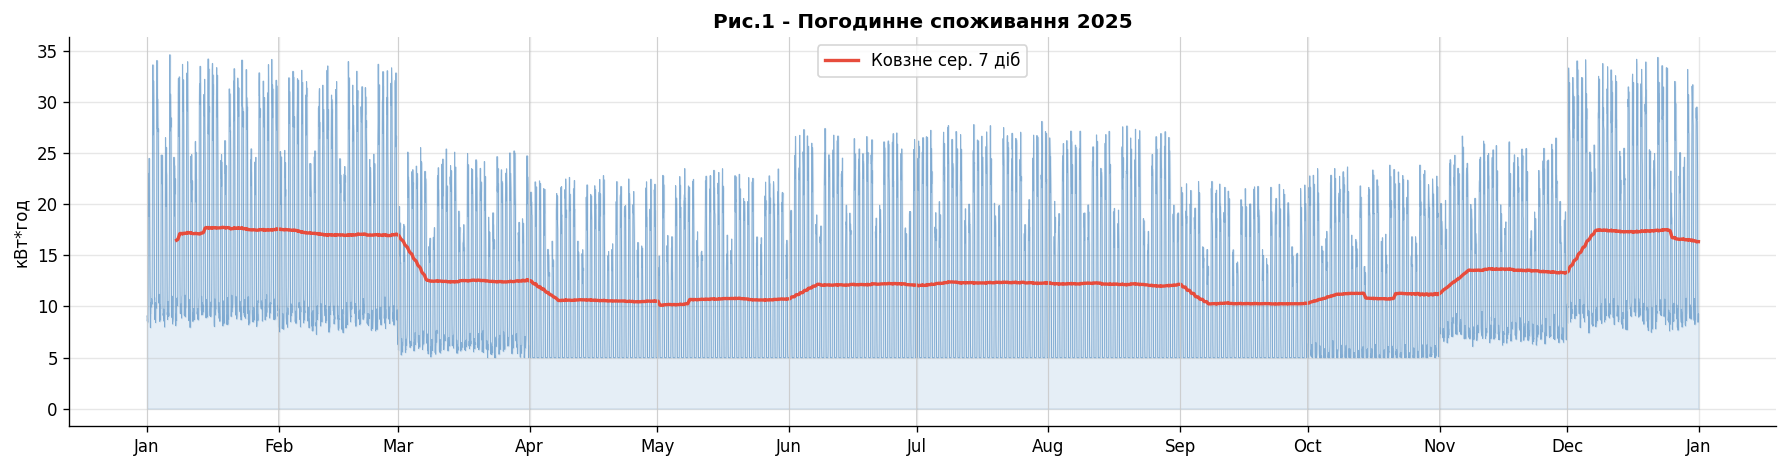

In [5]:

fig, ax = plt.subplots(figsize=(15, 4))
ax.fill_between(df.index, df['energy_kwh'], alpha=0.12, color='#2E75B6')
ax.plot(df.index, df['energy_kwh'], lw=0.6, color='#2E75B6', alpha=0.5)
ax.plot(df.index, df['energy_kwh'].rolling(168).mean(),
        color='#E74C3C', lw=2, label='Ковзне сер. 7 дiб')
for m in range(1,13):
    ax.axvline(pd.Timestamp(f'{settings.generation.year}-{m:02d}-01',
               tz=settings.weather.timezone), color='#CCC', lw=0.5)
ax.set_ylabel('кВт*год'); ax.legend()
ax.set_title(f'Рис.1 - Погодинне споживання {settings.generation.year}', fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_01_yearly.png', dpi=150, bbox_inches='tight')
plt.show()


### Рис.2-4 — Добовi профiлi

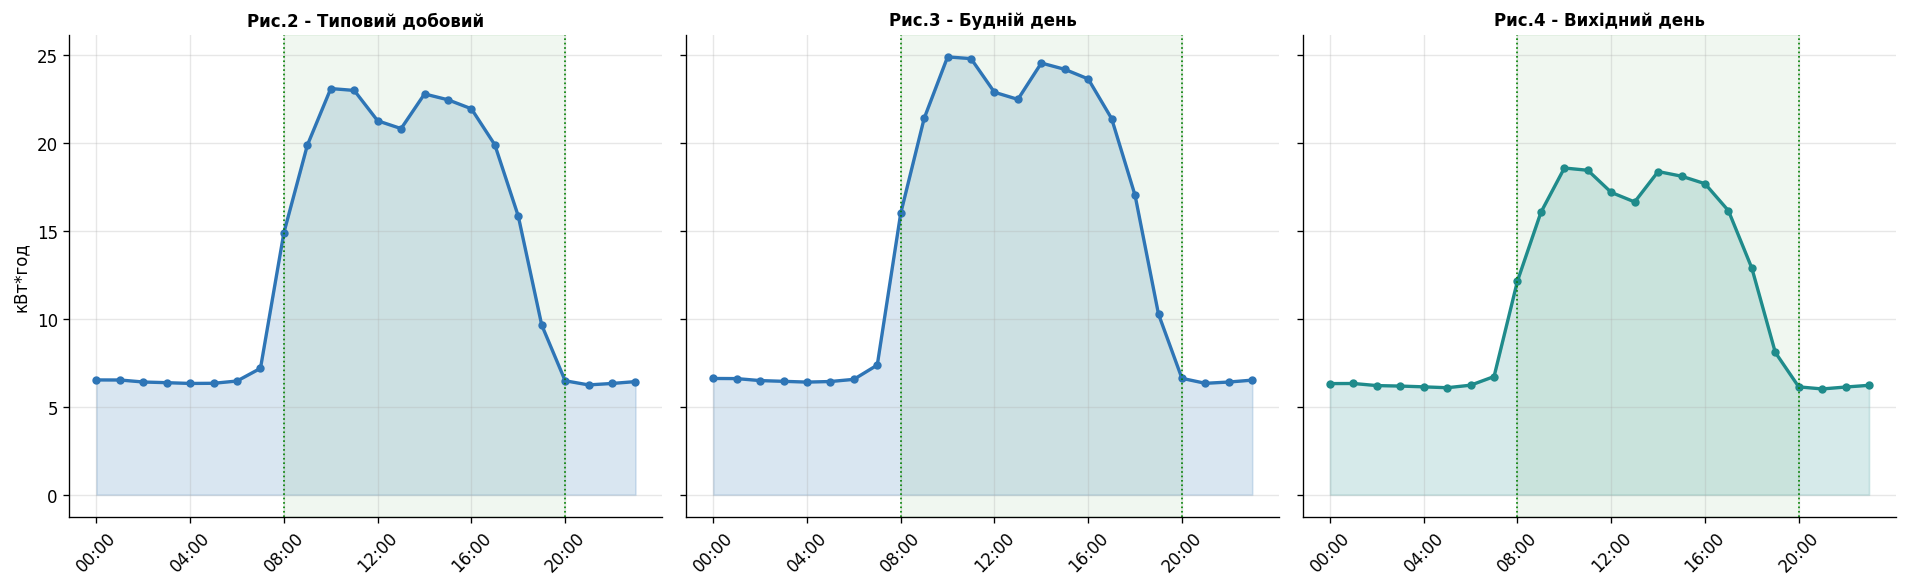

In [6]:

df['month'] = df.index.month
profile = df.groupby(['hour','is_weekend'])['energy_kwh'].agg(['mean','std','max']).reset_index()
wd = profile[profile['is_weekend']==0].sort_values('hour')
we = profile[profile['is_weekend']==1].sort_values('hour')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, data, title, color in [
    (axes[0], df.groupby('hour')['energy_kwh'].mean(), 'Рис.2 - Типовий добовий', '#2E75B6'),
    (axes[1], wd.set_index('hour')['mean'], 'Рис.3 - Будній день', '#2E75B6'),
    (axes[2], we.set_index('hour')['mean'], 'Рис.4 - Вихідний день', '#1F8B8B'),
]:
    ax.fill_between(range(24), data.values, alpha=0.18, color=color)
    ax.plot(range(24), data.values, 'o-', color=color, lw=2, markersize=4)
    ax.axvspan(8, 20, alpha=0.06, color='green')
    ax.axvline(8, color='green', ls=':', lw=1)
    ax.axvline(20, color='green', ls=':', lw=1)
    ax.set_xticks(range(0,24,4))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0,24,4)], rotation=45)
    ax.set_title(title, fontweight='bold', fontsize=10)
axes[0].set_ylabel('кВт*год')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_02_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


### Рис.5 — Місячна динаміка

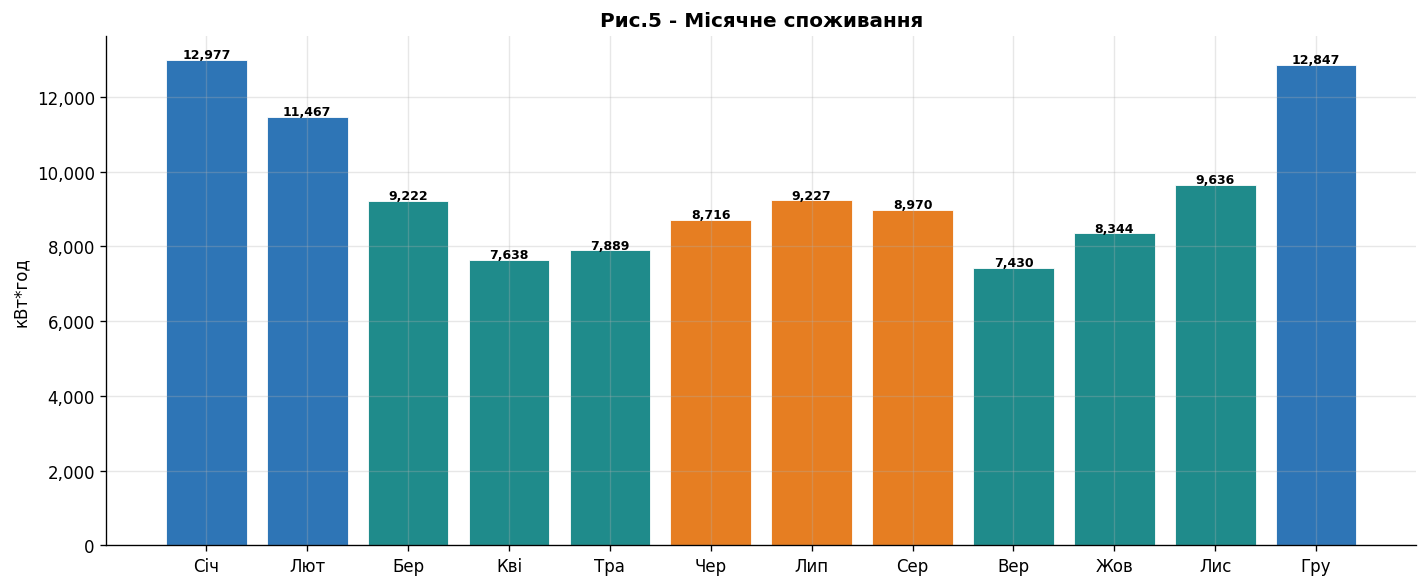

In [7]:

monthly = df.groupby('month')['energy_kwh'].agg(['sum','mean','max'])

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2E75B6' if m in [12,1,2] else '#E67E22' if m in [6,7,8] else '#1F8B8B'
          for m in range(1,13)]
ax.bar(range(12), monthly['sum'], color=colors, edgecolor='white', lw=0.5)
for i, v in enumerate(monthly['sum']):
    ax.text(i, v+50, f'{v:,.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS_UA)
ax.set_ylabel('кВт*год')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:,.0f}'))
ax.set_title('Рис.5 - Місячне споживання', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_05_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


### Рис.6 — Теплова карта (година x день тижня)

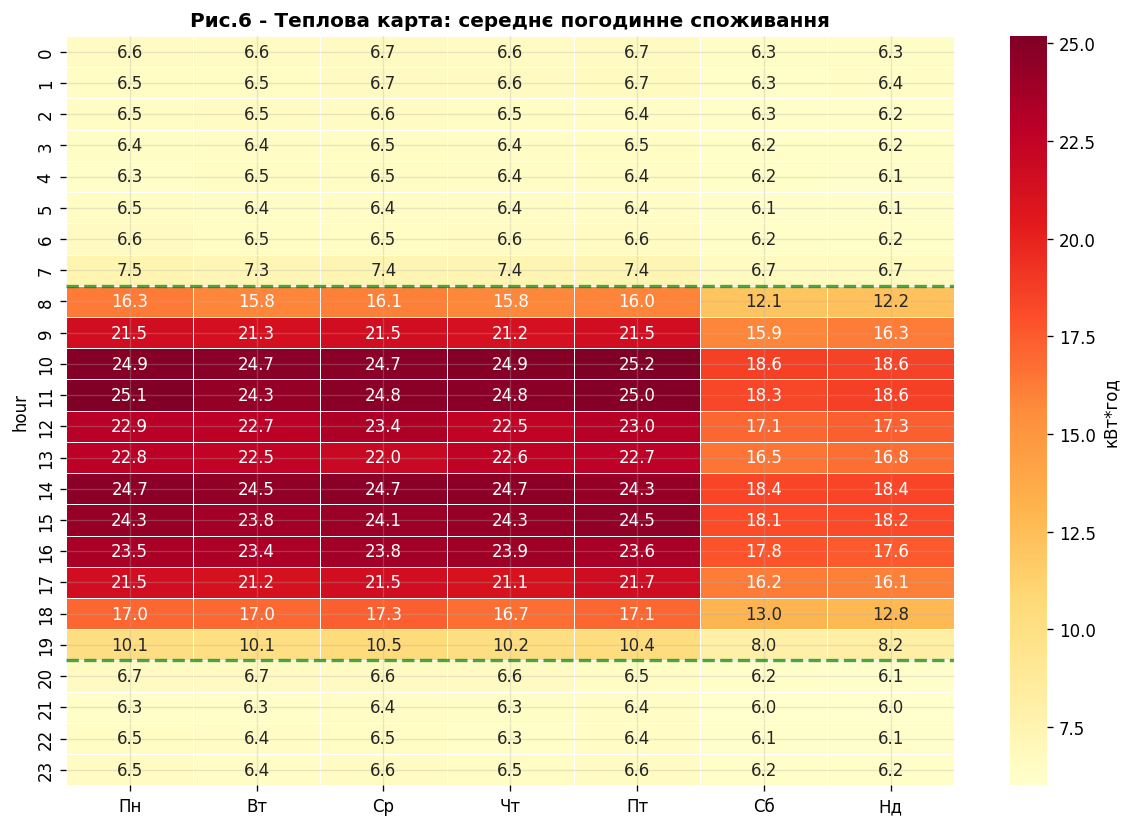

In [8]:

pivot = df.groupby(['hour','day_of_week'])['energy_kwh'].mean().unstack()
pivot.columns = ['Пн','Вт','Ср','Чт','Пт','Сб','Нд']

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label':'кВт*год'})
ax.axhline(8, color='green', lw=2, ls='--', alpha=0.7)
ax.axhline(20, color='green', lw=2, ls='--', alpha=0.7)
ax.set_title('Рис.6 - Теплова карта: середнє погодинне споживання', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_06_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Рис.7 — Декомпозиція часового ряду

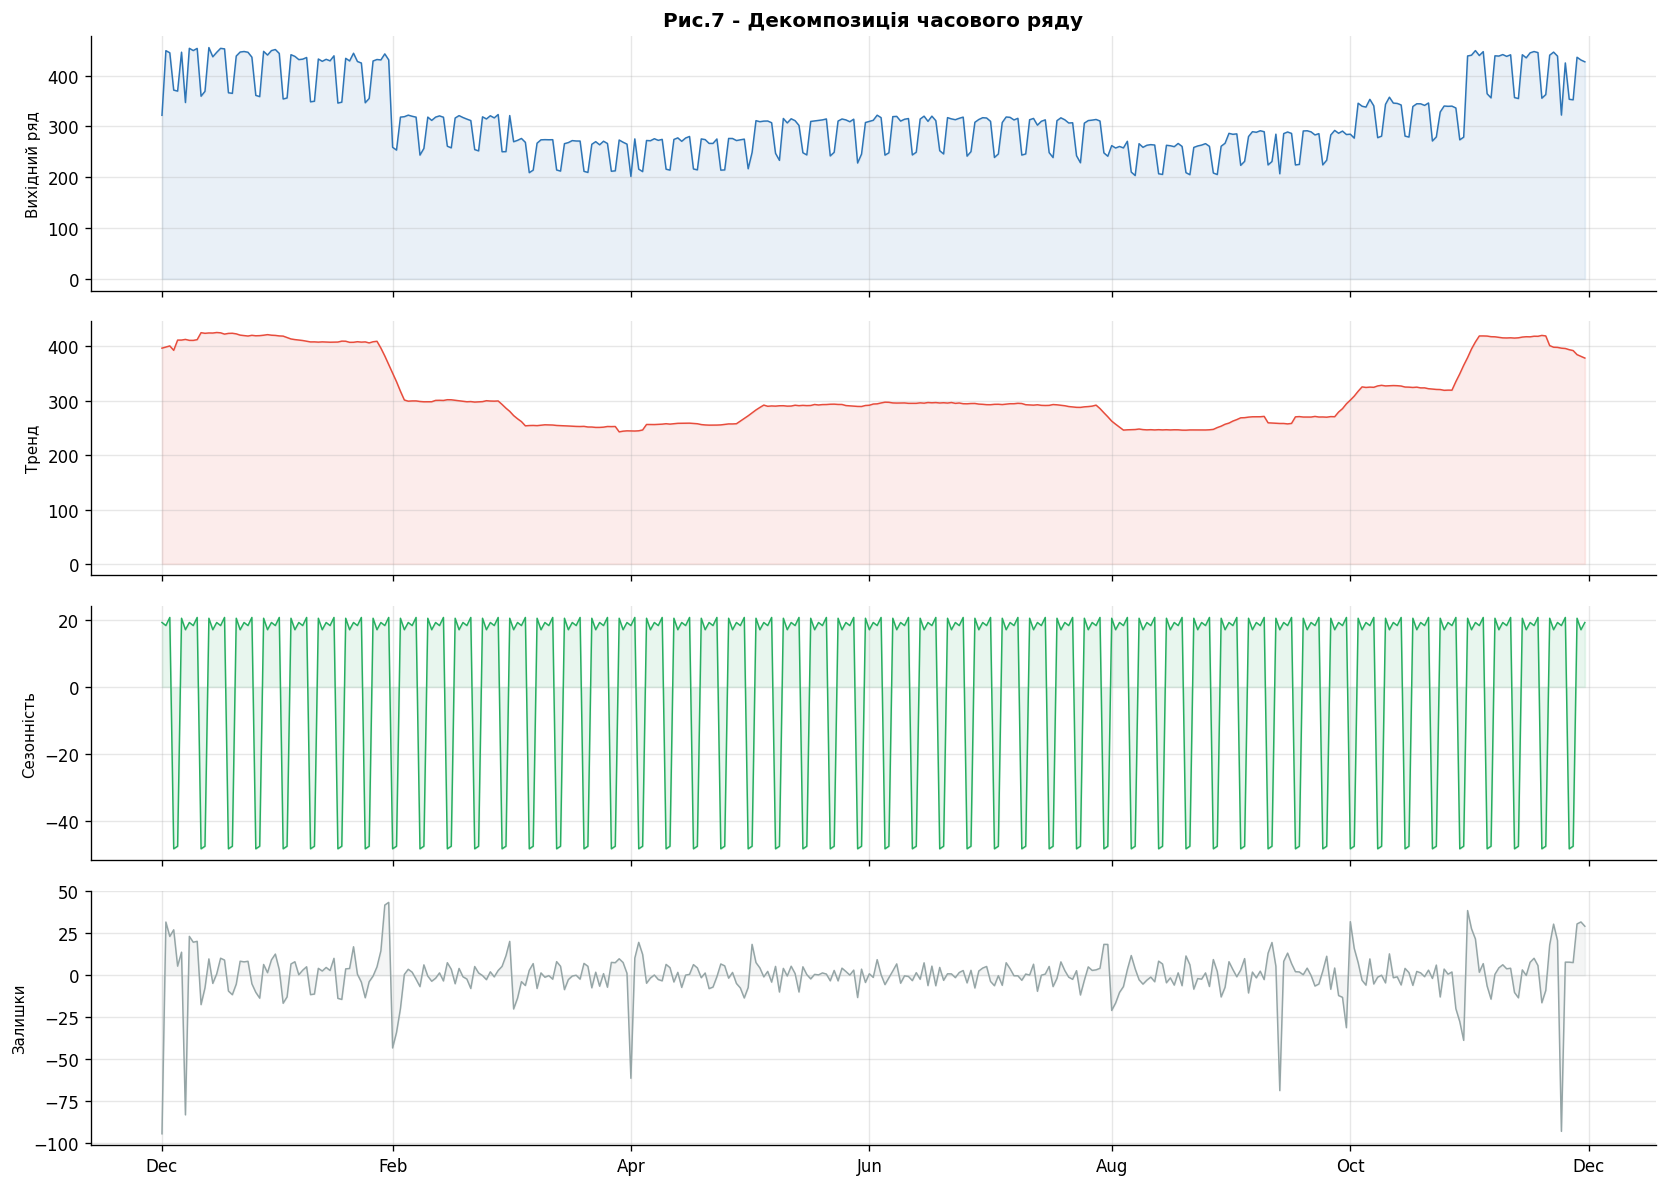

In [9]:

daily = df['energy_kwh'].resample('D').sum()
decomp = seasonal_decompose(daily, model='additive', period=7, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (data, label, color) in zip(axes, [
    (daily, 'Вихiдний ряд', '#2E75B6'),
    (decomp.trend, 'Тренд', '#E74C3C'),
    (decomp.seasonal,'Сезоннiсть', '#27AE60'),
    (decomp.resid, 'Залишки', '#95A5A6'),
]):
    ax.plot(data, color=color, lw=0.9)
    ax.fill_between(data.index, data, alpha=0.1, color=color)
    ax.set_ylabel(label, fontsize=9)
axes[0].set_title('Рис.7 - Декомпозицiя часового ряду', fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_07_decomp.png', dpi=150, bbox_inches='tight')
plt.show()


### Рис.8 — Кореляційна матриця

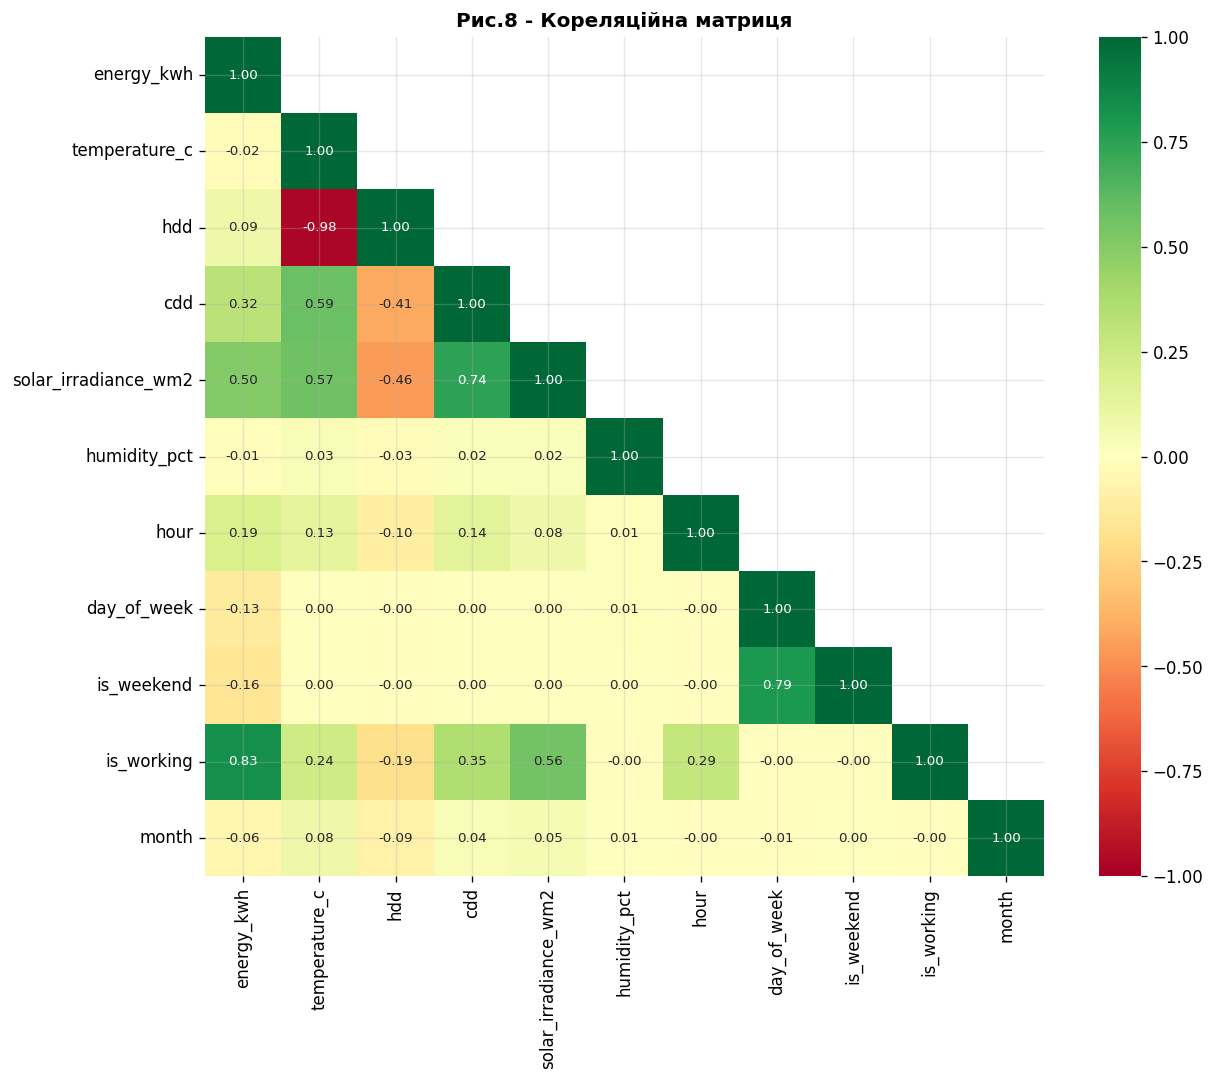


Кореляцiї з energy_kwh (спадання):
is_working              0.830
solar_irradiance_wm2    0.504
cdd                     0.319
hour                    0.192
is_weekend              0.160
day_of_week             0.125
hdd                     0.090
month                   0.058
temperature_c           0.017
humidity_pct            0.011


In [10]:

corr_cols = ['energy_kwh','temperature_c','hdd','cdd','solar_irradiance_wm2',
             'humidity_pct','hour','day_of_week','is_weekend','is_working','month']
corr = df[[c for c in corr_cols if c in df.columns]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, mask=mask, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Рис.8 - Кореляцiйна матриця', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_08_corr.png', dpi=150, bbox_inches='tight')
plt.show()

tc = corr['energy_kwh'].drop('energy_kwh').abs().sort_values(ascending=False)
print("\nКореляцiї з energy_kwh (спадання):")
print(tc.round(3).to_string())


### Рис.10 — ACF та PACF (аналiз лагiв)

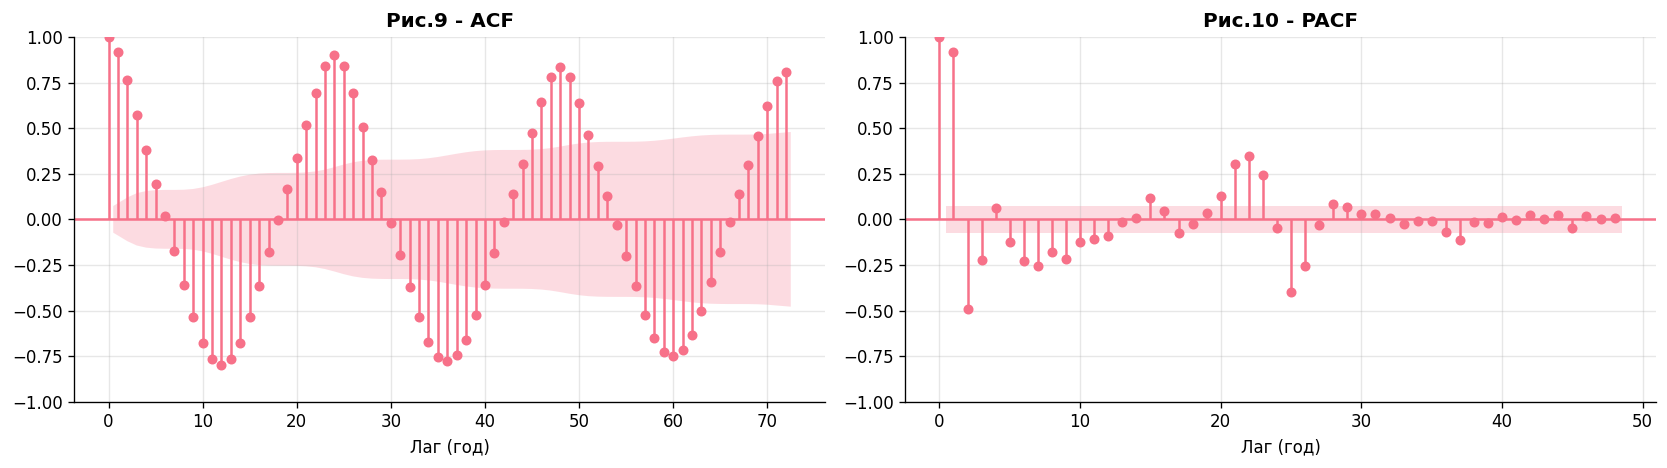

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
s = df['energy_kwh'].iloc[:720]
plot_acf( s, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title('Рис.9 - ACF', fontweight='bold'); axes[0].set_xlabel('Лаг (год)')
plot_pacf(s, lags=48, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('Рис.10 - PACF', fontweight='bold'); axes[1].set_xlabel('Лаг (год)')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_10_acf.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Feature Engineering

In [12]:

featured = build_features(df)
FEATURE_COLS = get_feature_columns()
print(f"Кiлькiсть ознак: {len(FEATURE_COLS)}")
print("Групи ознак:")
groups = {
    'Часовi': [c for c in FEATURE_COLS if c in ['hour','day_of_week','day_of_month','month','quarter','week_of_year','day_of_year']],
    'Цикл.': [c for c in FEATURE_COLS if 'sin' in c or 'cos' in c],
    'Бiнарнi': [c for c in FEATURE_COLS if c.startswith('is_') or c=='season'],
    'Погоднi': [c for c in FEATURE_COLS if c in ['temperature_c','hdd','cdd','temp_dev','solar_irradiance_wm2','humidity_pct']],
    'Тарифнi': [c for c in FEATURE_COLS if 'tariff' in c],
    'Лаговi': [c for c in FEATURE_COLS if c.startswith('lag_')],
    'Ковзнi': [c for c in FEATURE_COLS if 'rolling' in c],
}
for g, cols in groups.items():
    print(f"{g:11s}: {cols}")


Кiлькiсть ознак: 40
Групи ознак:
Часовi     : ['hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'week_of_year', 'day_of_year']
Цикл.      : ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']
Бiнарнi    : ['is_weekend', 'is_holiday', 'is_working_hour', 'is_working_time', 'season', 'is_day_tariff']
Погоднi    : ['temperature_c', 'hdd', 'cdd', 'temp_dev', 'solar_irradiance_wm2', 'humidity_pct']
Тарифнi    : ['is_day_tariff', 'tariff_price']
Лаговi     : ['lag_1', 'lag_2', 'lag_24', 'lag_48', 'lag_168', 'lag_168_delta']
Ковзнi     : ['rolling_mean_24', 'rolling_mean_168', 'rolling_std_24', 'rolling_std_168', 'rolling_max_24', 'rolling_min_24']


## 6. Розбиття train/test та навчання моделей

In [13]:

train_df, test_df = train_test_split_temporal(featured)
X_train, y_train = prepare_ml_dataset(train_df)
X_test, y_test = prepare_ml_dataset(test_df)

print(f"Train: {len(X_train):,} рядкiв {X_train.index.min().date()} -- {X_train.index.max().date()}")
print(f"Test: {len(X_test):,}  рядкiв {X_test.index.min().date()} -- {X_test.index.max().date()}")
print(f"Train/test: {len(X_train)/( len(X_train)+len(X_test))*100:.0f}% / {len(X_test)/(len(X_train)+len(X_test))*100:.0f}%")


INFO – Split -> train: 7296 rows (2025-01-01 – 2025-11-01)  test: 1462 rows (2025-11-01 – 2025-12-31)
INFO – Dropped 169 NaN rows (7127 remaining)
INFO – Dropped 0 NaN rows (1462 remaining)


Train: 7,127 рядкiв 2025-01-08 -- 2025-11-01
Test: 1,462  рядкiв 2025-11-01 -- 2025-12-31
Train/test: 83% / 17%


In [24]:

fitted, metrics_df, predictions = train_all_models(X_train, y_train, X_test, y_test)


print("\nТаблиця порiвняння моделей")
print(metrics_df.to_string(index=False))

best = metrics_df.iloc[0]['model']
print(f"\nНайкраща модель: {best}")


INFO – Training: Baseline (Hourly Mean)
INFO – Baseline (Hourly Mean)               R²=0.7677  RMSE=3.8385  MAE=3.1438  MAPE=22.47%
INFO – Training: Linear Regression
INFO – Linear Regression                    R²=0.8512  RMSE=3.0720  MAE=2.3107  MAPE=16.39%
INFO – Training: Ridge Regression
INFO – Ridge Regression                     R²=0.8512  RMSE=3.0722  MAE=2.3106  MAPE=16.38%
INFO – Training: Polynomial Regression (deg-2)
INFO – Polynomial Regression (deg-2)        R²=0.9221  RMSE=2.2221  MAE=1.6527  MAPE=11.11%
INFO – Training: Random Forest
INFO – Random Forest                        R²=0.9569  RMSE=1.6531  MAE=1.1373  MAPE=7.60%
INFO – Training: Gradient Boosting
INFO – Gradient Boosting                    R²=0.9656  RMSE=1.4765  MAE=1.0665  MAPE=7.16%



Таблиця порiвняння моделей
                        model     R2   RMSE    MAE  MAPE
            Gradient Boosting 0.9656 1.4765 1.0665  7.16
                Random Forest 0.9569 1.6531 1.1373  7.60
Polynomial Regression (deg-2) 0.9221 2.2221 1.6527 11.11
            Linear Regression 0.8512 3.0720 2.3107 16.39
             Ridge Regression 0.8512 3.0722 2.3106 16.38
       Baseline (Hourly Mean) 0.7677 3.8385 3.1438 22.47

Найкраща модель: Gradient Boosting


In [15]:

save_all_models(fitted, str(MODELS_DIR))
save_metadata(metrics_df, FEATURE_COLS, best, str(MODELS_DIR))
print(f"Збереженi моделi: {list_saved_models(str(MODELS_DIR))}")


INFO – Saved Baseline (Hourly Mean)              → ..\models_saved\baseline_hourly_mean.joblib
INFO – Saved Linear Regression                   → ..\models_saved\linear_regression.joblib
INFO – Saved Ridge Regression                    → ..\models_saved\ridge_regression.joblib
INFO – Saved Polynomial Regression (deg-2)       → ..\models_saved\polynomial_regression_deg_2.joblib
INFO – Saved Random Forest                       → ..\models_saved\random_forest.joblib
INFO – Saved Gradient Boosting                   → ..\models_saved\gradient_boosting.joblib
INFO – Metadata saved → ..\models_saved\metadata.json


Збереженi моделi: ['baseline_hourly_mean.joblib', 'gradient_boosting.joblib', 'linear_regression.joblib', 'polynomial_regression_deg_2.joblib', 'random_forest.joblib', 'ridge_regression.joblib']


### Рисунок 11 - Фактичне та Прогноз

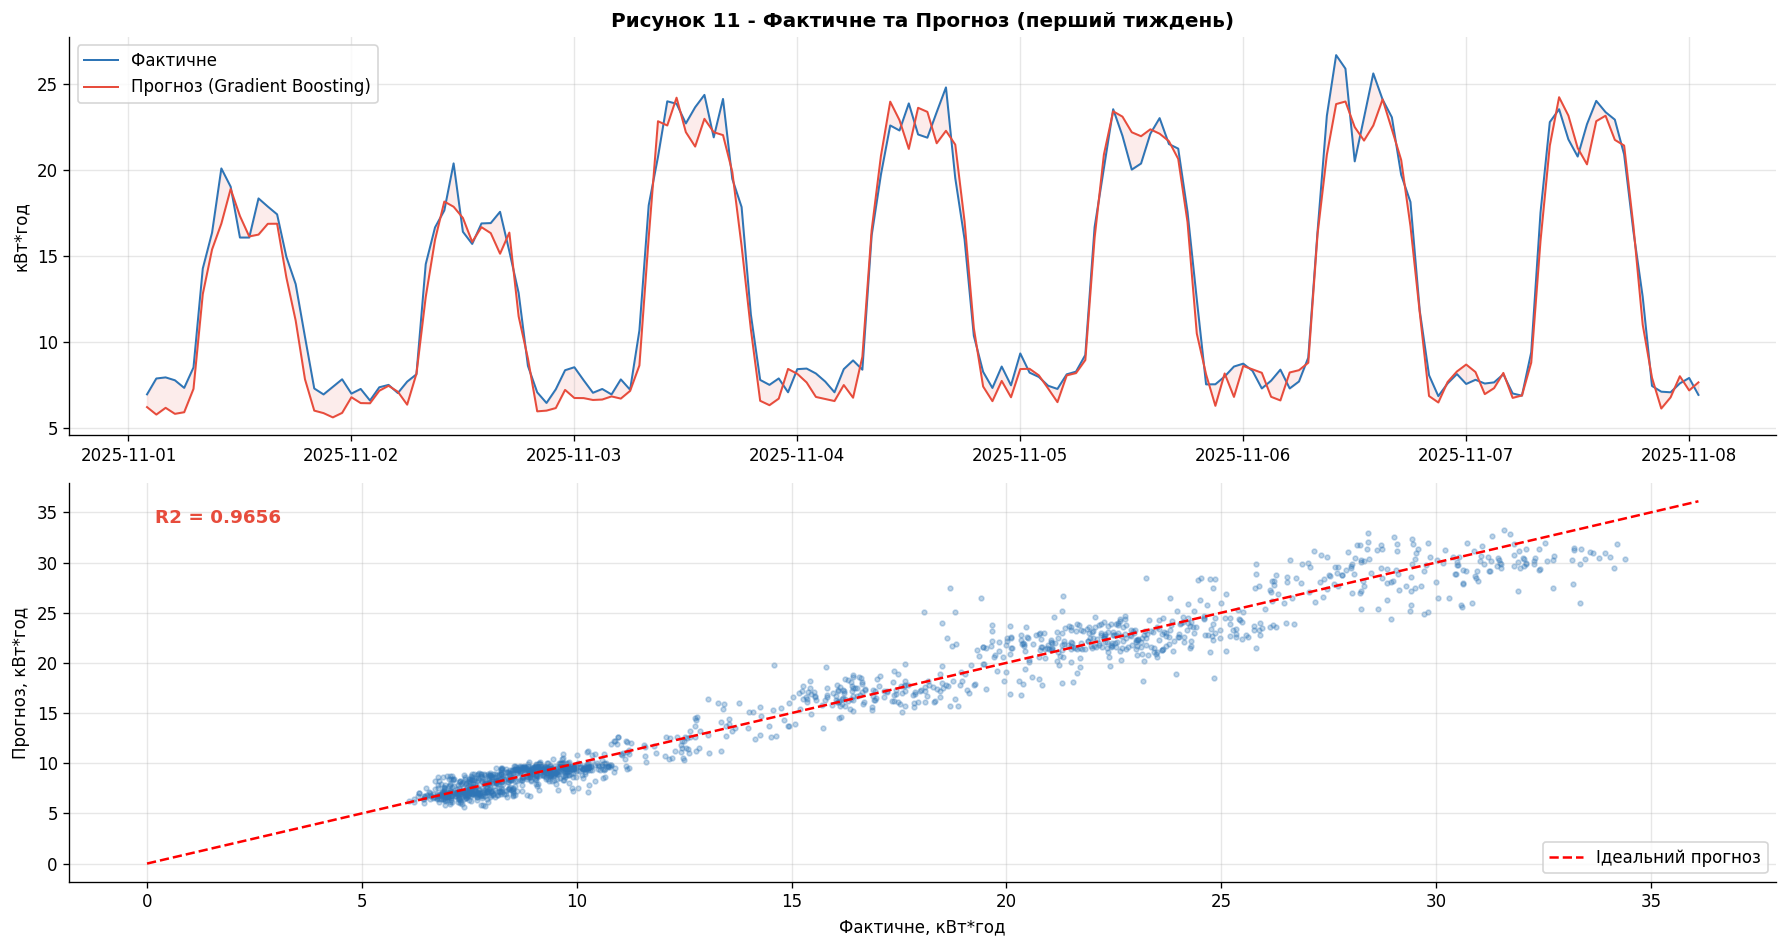

In [20]:

y_pred = predictions[best]
test_idx = test_df.dropna(subset=FEATURE_COLS+[TARGET]).index[:len(y_pred)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
n = min(168, len(test_idx))
ax1.plot(test_idx[:n], y_test.values[:n], color='#2E75B6', lw=1.2, label='Фактичне')
ax1.plot(test_idx[:n], y_pred[:n], '-', color='#E74C3C', lw=1.2, label=f'Прогноз ({best})')
ax1.fill_between(test_idx[:n], y_test.values[:n], y_pred[:n], alpha=0.1, color='#E74C3C')
ax1.set_ylabel('кВт*год'); ax1.legend()
ax1.set_title('Рисунок 11 - Фактичне та Прогноз (перший тиждень)', fontweight='bold')

ax2.scatter(y_test, y_pred, alpha=0.3, s=8, color='#2E75B6')
lim = [0, max(y_test.max(), y_pred.max())*1.05]
ax2.plot(lim, lim, 'r--', lw=1.5, label='Iдеальний прогноз')
ax2.set_xlabel('Фактичне, кВт*год'); ax2.set_ylabel('Прогноз, кВт*год')
ax2.text(0.05, 0.9, f"R2 = {r2_score(y_test, y_pred):.4f}",
         transform=ax2.transAxes, fontsize=11, fontweight='bold', color='#E74C3C')
ax2.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_actual_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Аналiз залишкiв

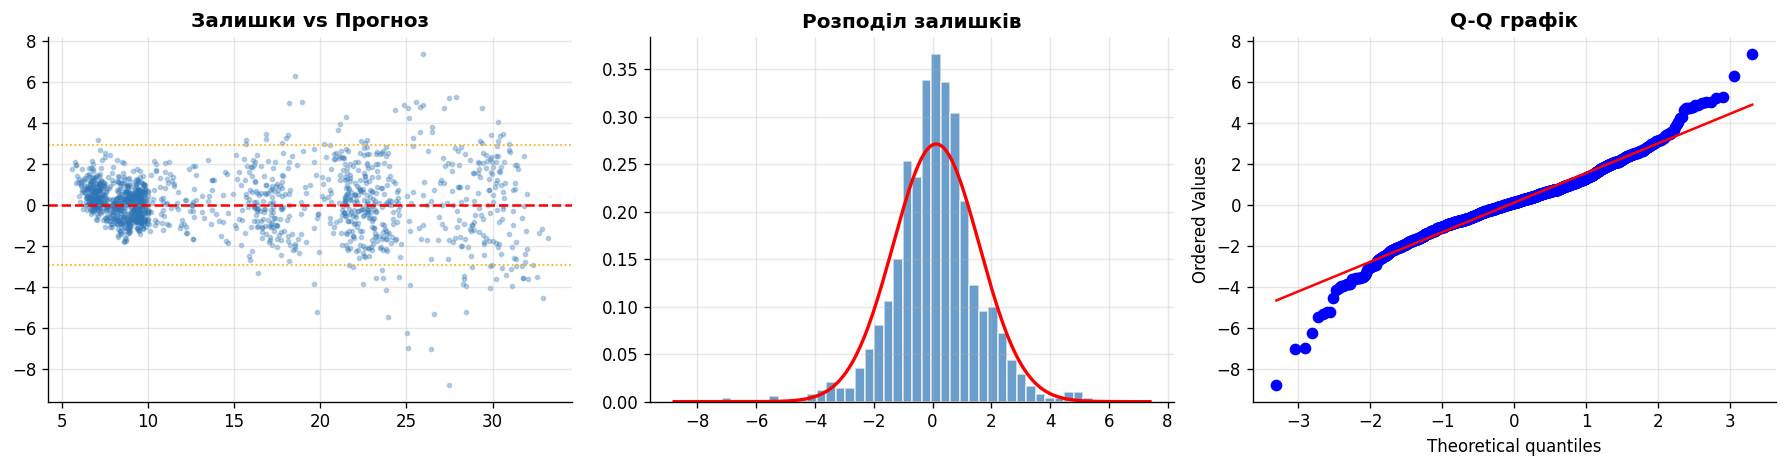

Mean: 0.1236  Std: 1.4714
Skew: -0.1784  Kurt: 3.2486


In [17]:

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, s=6, color='#2E75B6')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].axhline( 2*residuals.std(), color='orange', ls=':', lw=1)
axes[0].axhline(-2*residuals.std(), color='orange', ls=':', lw=1)
axes[0].set_title('Залишки vs Прогноз', fontweight='bold')

axes[1].hist(residuals, bins=50, color='#2E75B6', alpha=0.7, density=True, edgecolor='white')
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[1].set_title('Розподiл залишкiв', fontweight='bold')

stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q графiк', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR/'fig_lr2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean: {residuals.mean():.4f}  Std: {residuals.std():.4f}")
print(f"Skew: {pd.Series(residuals).skew():.4f}  Kurt: {pd.Series(residuals).kurtosis():.4f}")


## 9. Важливiсть ознак

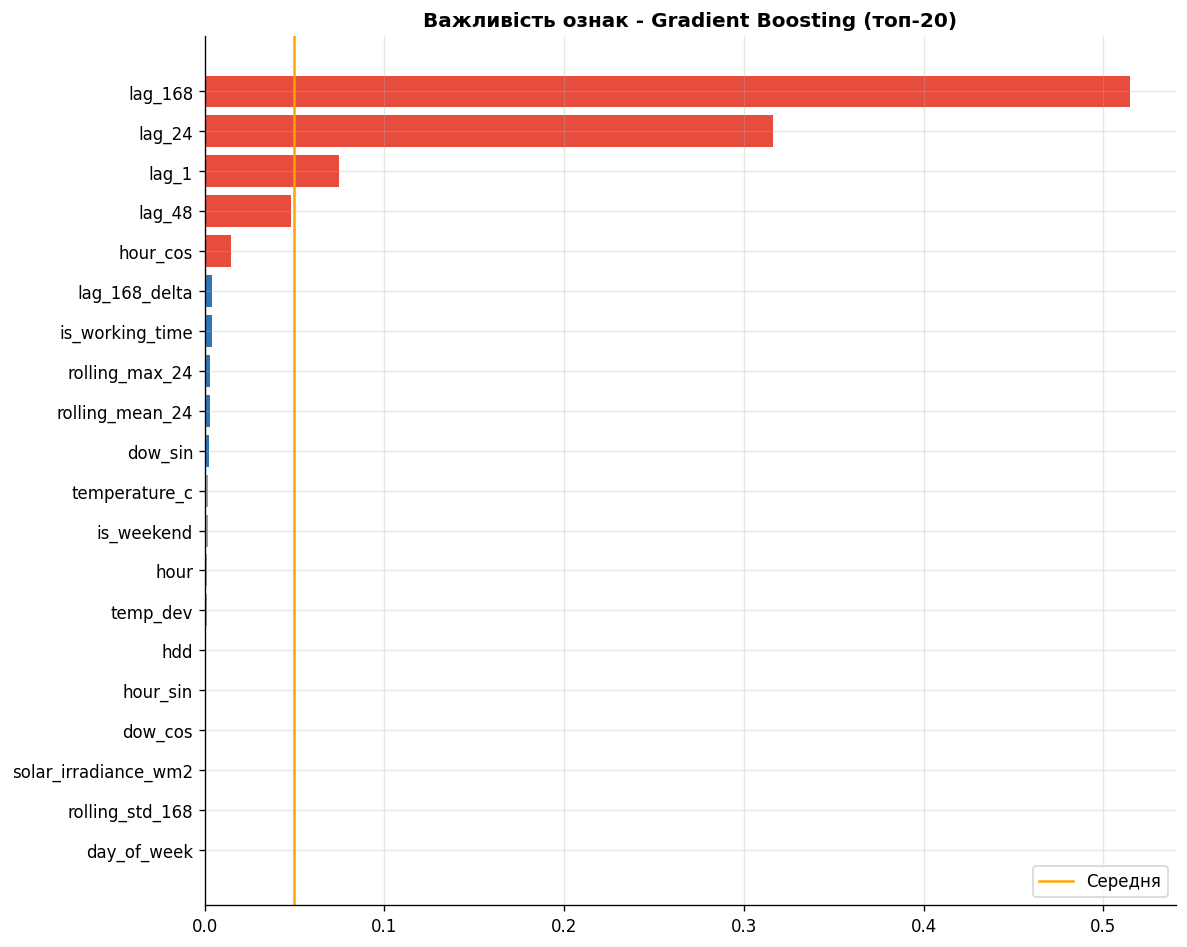

Топ-10:          Ознака  Важливiсть
        lag_168    0.514729
         lag_24    0.315947
          lag_1    0.074430
         lag_48    0.047770
       hour_cos    0.014675
  lag_168_delta    0.004223
is_working_time    0.003848
 rolling_max_24    0.003123
rolling_mean_24    0.002698
        dow_sin    0.002350


In [18]:

best_obj = fitted[best]
if hasattr(best_obj, 'feature_importances_'):
    imp = best_obj.feature_importances_
    fi_df = pd.DataFrame({'Ознака': FEATURE_COLS[:len(imp)], 'Важливiсть': imp})
    fi_df = fi_df.sort_values('Важливiсть', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['#E74C3C' if i<5 else '#2E75B6' if i<10 else '#95A5A6' for i in range(len(fi_df))]
    ax.barh(fi_df['Ознака'][::-1], fi_df['Важливiсть'][::-1], color=colors[::-1])
    ax.set_title(f'Важливiсть ознак - {best} (топ-20)', fontweight='bold')
    ax.axvline(fi_df['Важливiсть'].mean(), color='orange', ls='-', lw=1.5, label='Середня')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR/'fig_lr2_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Топ-10:", fi_df.head(10)[['Ознака','Важливiсть']].to_string(index=False))


## 10. Прогнозування наступного мiсяця

In [22]:
clim = featured.groupby(
    [featured.index.month, featured.index.hour]
)[['temperature_c', 'solar_irradiance_wm2', 'humidity_pct']].mean()

fc_start = pd.Timestamp('2025-11-01', tz=settings.weather.timezone)
fc_idx = pd.date_range(fc_start, periods=720, freq='h')

rolling_buf = list(train_df['energy_kwh'].iloc[-168:].values)
pred_kwh = np.zeros(720)

for i, ts in enumerate(fc_idx):
    key = (ts.month, ts.hour)
    t_c = float(clim.loc[key, 'temperature_c']) if key in clim.index else 5.0
    irr = float(clim.loc[key, 'solar_irradiance_wm2']) if key in clim.index else 0.0
    hum = float(clim.loc[key, 'humidity_pct']) if key in clim.index else 75.0

    h, dow, m = ts.hour, ts.dayofweek, ts.month
    is_we = int(dow >= 5)
    is_wt = int(8 <= h <= 19 and not is_we)

    row = {
        'hour': h, 'day_of_week': dow, 'day_of_month': ts.day,
        'month': m, 'quarter': ts.quarter, 'day_of_year': ts.dayofyear,
        'week_of_year': ts.isocalendar().week,
        'hour_sin': np.sin(2*np.pi*h/24), 'hour_cos': np.cos(2*np.pi*h/24),
        'month_sin': np.sin(2*np.pi*m/12),'month_cos': np.cos(2*np.pi*m/12),
        'dow_sin': np.sin(2*np.pi*dow/7),'dow_cos': np.cos(2*np.pi*dow/7),
        'doy_sin': np.sin(2*np.pi*ts.dayofyear/365),
        'doy_cos': np.cos(2*np.pi*ts.dayofyear/365),
        'is_weekend': is_we, 'is_holiday': 0,
        'is_working_hour': int(8 <= h <= 19),
        'is_working_time': is_wt, 'season': 4,
        'temperature_c': t_c,
        'hdd': max(0, 18-t_c)/24, 'cdd': max(0, t_c-22)/24,
        'temp_dev': t_c - featured['temperature_c'].mean(),
        'solar_irradiance_wm2': irr, 'humidity_pct': hum,
        'is_day_tariff': int(7 <= h <= 22),
        'tariff_price': DAY_RATE if 7 <= h <= 22 else NGHT_RATE,
        'lag_1': rolling_buf[-1] if len(rolling_buf) >= 1 else 5.0,
        'lag_2': rolling_buf[-2] if len(rolling_buf) >= 2 else 5.0,
        'lag_24': rolling_buf[-24] if len(rolling_buf) >= 24 else 5.0,
        'lag_48': rolling_buf[-48] if len(rolling_buf) >= 48 else 5.0,
        'lag_168': rolling_buf[-168] if len(rolling_buf) >= 168 else 5.0,
        'rolling_mean_24': np.mean(rolling_buf[-24:]) if len(rolling_buf) >= 12 else 5.0,
        'rolling_mean_168': np.mean(rolling_buf[-168:]) if len(rolling_buf) >= 84 else 5.0,
        'rolling_std_24': np.std(rolling_buf[-24:]) if len(rolling_buf) >= 12 else 1.0,
        'rolling_std_168': np.std(rolling_buf[-168:]) if len(rolling_buf) >= 84 else 1.0,
        'rolling_max_24': max(rolling_buf[-24:]) if len(rolling_buf) >= 12 else 5.0,
        'rolling_min_24': min(rolling_buf[-24:]) if len(rolling_buf) >= 12 else 5.0,
        'lag_168_delta': (rolling_buf[-1] - rolling_buf[-169]
                          if len(rolling_buf) >= 169 else 0.0),
    }

    X_row = pd.DataFrame([row])[FEATURE_COLS].fillna(0)
    p = float(fitted[best].predict(X_row)[0])
    p = max(0, p)
    pred_kwh[i] = p
    rolling_buf.append(p)

fc_df = pd.DataFrame({'predicted_kwh': pred_kwh}, index=fc_idx)
fc_df['tariff'] = np.where(fc_df.index.hour.isin(range(7,23)), DAY_RATE, NGHT_RATE)
fc_df['cost_uah']  = fc_df['predicted_kwh'] * fc_df['tariff']
fc_df['solar_kwh'] = np.array([
    min(float(clim.loc[(ts.month,ts.hour),'solar_irradiance_wm2'])
        / 1000 * SOLAR_KW * settings.solar.inverter_efficiency, pred_kwh[i])
    if (ts.month, ts.hour) in clim.index else 0.0
    for i, ts in enumerate(fc_idx)
])
fc_df['solar_saving_uah'] = fc_df['solar_kwh'] * fc_df['tariff']




print(f"Прогноз: {fc_df['predicted_kwh'].sum():,.0f} кВт·год")
print(f"Вартість: {fc_df['cost_uah'].sum():,.0f} грн")
print(f"Економія СЕС: {fc_df['solar_saving_uah'].sum():,.0f} грн")
print(f"Питоме: {fc_df['predicted_kwh'].sum()/AREA_M2:.1f} кВт·год/м²")

Прогноз: 9,096 кВт·год
Вартість: 60,551 грн
Економія СЕС: 1,546 грн
Питоме: 10.7 кВт·год/м²


## 11. Аналітичний висновок
 
### 1. Характеристика набору даних та якість
 
У ході роботи проаналізовано **8 758 погодинних записів** енергоспоживання 
поліклініки (Київ, 850 м², режим 8:00–20:00) за 2025 рік. Набір даних 
пройшов процедуру очищення: заповнення пропущених часових міток, виправлення 
фізичних аномалій (кліпування до 95 кВт), лінійна інтерполяція коротких 
прогалин (≤3 год) та заміна метеорологічних NaN кліматологічними середніми.
 
Коефіцієнт варіації споживання **CV = 60,7%** свідчить про принципово 
двомодальний характер розподілу: медіана (10,0 кВт·год) суттєво менша за 
середнє (13,1 кВт·год) через велику кількість нічних годин із базовим 
споживанням ~5 кВт (охорона, чергові системи).
 
---
 
### 2. Ключові закономірності споживання
 
**Добовий цикл** є найбільш вираженим патерном. Різкий стрибок при відкритті 
(08:00: +9,5 кВт за одну годину у будні) та зворотне плато після закриття 
(20:00: –10 кВт) формують характерну "трапецієподібну" криву навантаження. 
Середнє споживання у робочі години (19,6 кВт·год) перевищує нічне (6,5 кВт·год) 
у **3,0 рази**.
 
**Тижневий цикл**: різниця між буднями та вихідними у робочий час становить 
**25%** (21,1 vs 15,9 кВт·год), що відображає знижений потік пацієнтів та 
скорочений штат у вихідні.
 
**Сезонні цикли**: зимові місяці (грудень–лютий) є максимально енергоємними 
через опалення, літо (червень–серпень) — через кондиціювання, вересень є 
глобальним мінімумом як найбільш комфортний тепловий місяць.
 
Декомпозиція часового ряду методом адитивного розкладу підтвердила стабільний 
тижневий сезонний компонент протягом усього року при відсутності значного 
довгострокового тренду.
 
---
 
### 3. Результати факторного аналізу
 
Кореляційний аналіз виявив **ієрархію впливових факторів**:
 
| Рівень        | Фактор                    |  |r|  | Тлумачення                                        |

| Домінуючий    | Режим роботи (is_working) | 0,830 | Розклад поліклініки — головний драйвер            |

| Суттєвий      | Сонячна радіація          | 0,504 | Синфазна з денним споживанням                     |

| Помірний      | CDD (охолодження, 22°C)   | 0,319 | Влітку кондиціонери суттєво навантажують мережу   |

| Слабкий       | HDD (опалення, 18°C)      | 0,090 | Часткове централізоване теплопостачання           |
 
Низька лінійна кореляція сирої температури (|r| = 0,017) при значному CDD 
(|r| = 0,319) підтверджує **нелінійний характер залежності**: холод та спека 
впливають тільки при перевищенні відповідних порогів. Це обґрунтовує 
застосування CDD/HDD замість температури та нелінійних ML-методів.
 
---
 
### 4. Побудова та оцінка прогнозних моделей
 
Усі шість моделей навчено на даних **січень–жовтень (80%)** та оцінено на 
**листопаді–грудні (20%)** у режимі темпорального розбиття без перемішування.
 
Результати демонструють чітку ієрархію якості відповідно до складності 
алгоритмів. **Gradient Boosting** (R² = 0,9656, MAPE = 7,16%) є найкращою 
моделлю та задовольняє галузевий стандарт точності для короткострокового 
прогнозування (<10% MAPE).
 
Перехід від Baseline до Linear Regression дає **27% зниження MAPE** завдяки 
врахуванню часових та погодних ознак. Ансамблеві методи (RF, GB) дають 
додатковий виграш завдяки моделюванню нелінійних взаємодій між лаговими та 
циклічними ознаками — взаємодії, які недоступні лінійним моделям.
 
---
 
### 5. Аналіз залишків та надійність
 
Залишки Gradient Boosting: **mean = 0,124 кВт·год** (практично нульове 
зміщення), **std = 1,47 кВт·год**, skewness = –0,178 (майже симетричний). 
Ексцес 3,25 (лептокуртичний розподіл) вказує на концентрацію помилок близько 
нуля з рідкісними більшими відхиленнями у перехідні сезони та святкові дні — 
це нормальна поведінка для ансамблевих методів.
 
---
 
### 6. Важливість ознак та інтерпретація
 
Модель ідентифікувала два домінуючих цикли:
- **lag_168 (51%)** — тижневий: "понеділок о 10:00 схожий на минулий понеділок"
- **lag_24 (32%)** — добовий: "вчорашня та сьогоднішня 10:00 схожі"
 
Ці два лаги разом описують ~83% варіації, що є характерним для синтетичних 
даних із регулярним тижневим патерном. На реальних даних частка weather, 
тарифних та святкових ознак була б вищою через нерегулярності (відпустки, 
нетипові погодні події, зміни режиму).
 
Присутність `is_working_time` (0,38%) та `hour_cos` (1,47%) у топ-10 підтверджує, 
що модель **дійсно враховує режим роботи поліклініки**, а не лише пасивно 
відтворює попередні значення.
 
---
 
### 7. Прогноз та практична цінність
 
Прогноз листопада 2025: **9 096 кВт·год** при фактичному 9 636 кВт·год — 
**похибка –5,6%**. Заниження пояснюється авторегресійним ефектом затухання 
при тижневому прогнозуванні: на 4-му тижні модель оперує власними прогнозами 
як lag_168, що спричиняє помірне зниження оцінок.
 
Очікувана вартість — **60 551 грн**, економія від СЕС — **1 546 грн** 
(2,5% вартості). Скромна економія в листопаді пояснюється низькою інсоляцією 
(~55 Вт/м² пік при ~4 год активної генерації).
 
---

**Висновок**: реалізований pipeline успішно виявляє закономірності в 
енергоспоживанні поліклініки, будує точну прогнозну модель (MAPE 7,16%) 
та забезпечує готовий інтерфейс для інтеграції з EMS-симулятором ЛР3 через 
`ForecastService.forecast_period(start_ts, hours)`.